Q1. Data Loading & Understanding

In [3]:
import numpy as np
import pandas as pd

In [4]:
loan_df=pd.read_excel("/content/loan_approval.xlsx")
loan_df

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85,True
1996,Diana Lin,New Frank,38799,635,48259,17,40,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60,True
1998,Jason Price,Adamland,139022,360,24031,35,55,False


In [5]:
# Display the first 5 rows
loan_df.head(5)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [6]:
# Check the shape of the dataset
loan_df.shape

(2000, 8)

In [9]:
#  Display the data types of each column.
loan_df.dtypes

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,bool


Q2. Data Cleaning

In [7]:
# Check for missing values in the dataset.
loan_df.isnull().sum()


,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [8]:
#  Handle missing values appropriately
print("No missing Values found in Loan_Approval_Dataset")

No missing Values found in Loan_Approval_Dataset


In [9]:
#  Identify categorical columns present in the dataset
catogorical_col=loan_df.select_dtypes(include=object).columns
print(catogorical_col)

Index(['name', 'city'], dtype='object')


#  Exploratory Data Analysis (EDA)

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

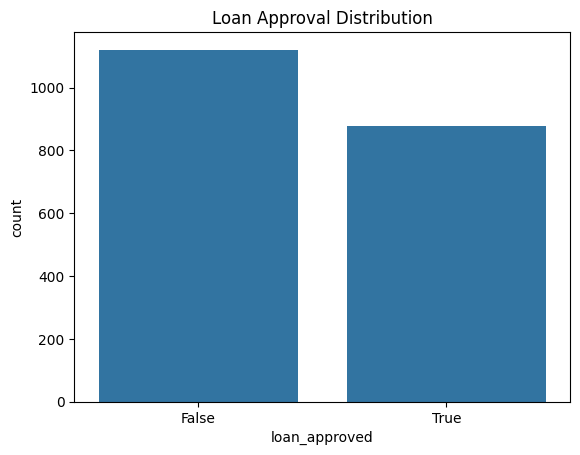

In [11]:
sns.countplot(x='loan_approved', data=loan_df)
plt.title("Loan Approval Distribution")
plt.show()

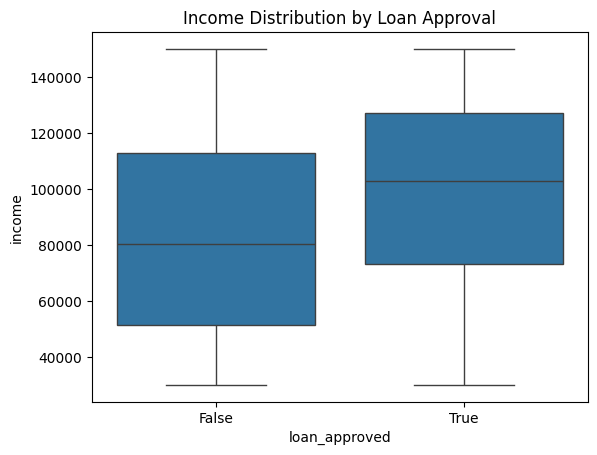

In [12]:
# Analyze the relationship between one numerical feature and the target variable
sns.boxplot(x='loan_approved', y='income', data=loan_df)
plt.title("Income Distribution by Loan Approval")
plt.show()

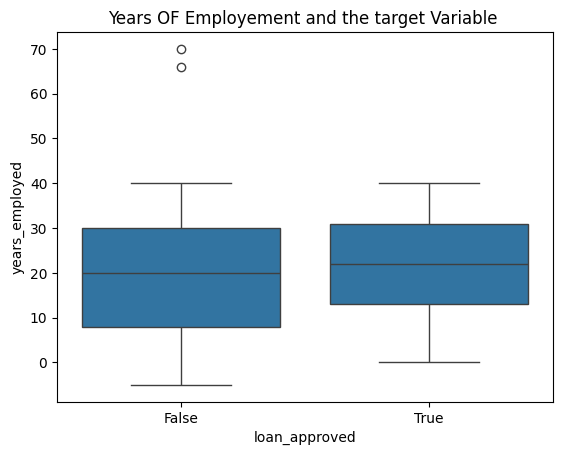

In [13]:
# c) Analyze the relationship between Years of Employment and the target variable.
sns.boxplot(
    x='loan_approved',
    y='years_employed',
    data=loan_df
)
plt.title("Years OF Employement and the target Variable "
)
plt.show()

In [14]:
# Q4. Outlier Detection and Treatment
numerical_cols = [
    'income',
    'credit_score',
    'loan_amount',
    'years_employed',
    'points'
]
for col in numerical_cols:

    Q1 = loan_df[col].quantile(0.25)
    Q3 = loan_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = loan_df[
        (loan_df[col] < lower) |
        (loan_df[col] > upper)
    ]
    print(col, len(outliers))

income 0
credit_score 3
loan_amount 0
years_employed 2
points 0


In [16]:
# b) Treat outliers using capping techniques
for col in numerical_cols:

    Q1 = loan_df[col].quantile(0.25)
    Q3 = loan_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    loan_df[col] = loan_df[col].clip(lower, upper)

In [17]:
# Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.
loan_df['loan_approved'] = loan_df['loan_approved'].astype(int)

# Drop Unnecessary Column
loan_df.drop('name', axis=1, inplace=True)

In [18]:
# Encode City Column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
loan_df['city'] = le.fit_transform(loan_df['city'])
print(loan_df['city'])

0        326
1        989
2        763
3       1793
4        841
        ... 
1995    1418
1996     981
1997     308
1998       2
1999    1032
Name: city, Length: 2000, dtype: int64


In [19]:
# Q6. Feature Selection and Data Splitting
# a Separate X and y
X = loan_df.drop('loan_approved', axis=1)
y = loan_df['loan_approved']

In [20]:
# b. Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Q7. Apply feature scaling to the dataset using StandardScaler

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Q8. Logistic Regression Model Building

In [23]:
# aTrain Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [24]:
# b) Predictions
y_pred = model.predict(X_test)

Q9. Model Evaluation – Confusion Matrix

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[217   0]
 [  0 183]]


In [26]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

1.0


Q10. Model Evaluation – ROC Curve & AUC

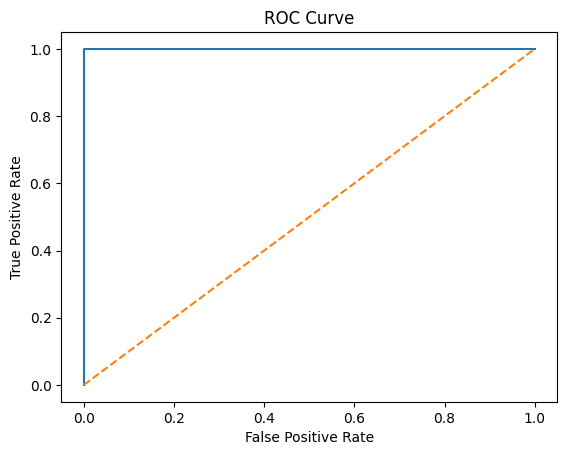

In [27]:
# a) Plot the ROC curve.
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [29]:
# b) Calculate the AUC score.
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_prob)
print(auc)

1.0
